# LitBench: Quality Analysis with 4 Diversity Metrics

**Goal:** Test whether the 4 diversity dimensions (D_sem, D_lex, D_syn, D_disc) correlate with human quality preferences

**Approach:** 
- Compute **intra-story diversity** for each metric (diversity within a sentence)
- Higher intra-story diversity -> more varied syntax, richer semantics, or more complex discourse structure

**Data source:** [LitBench](https://huggingface.co/collections/SAA-Lab/litbench) -> 43.8k pairwise story comparisons from WritingPrompts with human preference labels (upvotes)

| Metric | Operationalization (intra-story) |
|---|---|
| $D_{\text{sem}}$ | Mean pairwise SBERT cosine distance between sentences |
| $D_{\text{lex}}$ | Mean pairwise Jaccard distance on word bigrams between sentences |
| $D_{\text{syn}}$ | Mean pairwise Jaccard distance on POS trigrams between sentences |
| $D_{\text{disc}}$ | Entropy of entity grid transition distribution |

In [18]:
# Load packages
import numpy as np
import pandas as pd
import json, re, time, warnings
from collections import Counter
from itertools import combinations
from scipy.stats import entropy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import spacy
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

warnings.filterwarnings('ignore')
np.random.seed(42)

nlp = spacy.load('en_core_web_sm')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('spaCy and SBERT loaded.')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9140.04it/s]


spaCy and SBERT loaded.


In [19]:
# Load dataset
ds = load_dataset('SAA-Lab/LitBench-Train', split='train')
df = ds.to_pandas()

print(f'LitBench loaded: {len(df):,} pairs')
print(f'Columns: {list(df.columns)}')
print(f'\nExample:')
print(f'  Prompt:  "{df.iloc[0]["prompt"][:100]}..."')
print(f'  Chosen:  {len(df.iloc[0]["chosen_story"]):,} chars, {df.iloc[0]["chosen_upvotes"]} upvotes')
print(f'  Rejected: {len(df.iloc[0]["rejected_story"]):,} chars, {df.iloc[0]["rejected_upvotes"]} upvotes')

LitBench loaded: 43,827 pairs
Columns: ['prompt', 'chosen_story', 'rejected_story', 'chosen_timestamp', 'rejected_timestamp', 'chosen_upvotes', 'rejected_upvotes']

Example:
  Prompt:  "[WP] In this world, soulmates cannot hurt each other in any way or form, intentionally or unintentio..."
  Chosen:  389 chars, 102 upvotes
  Rejected: 8,116 chars, 22 upvotes


## Diversity Metrics (intra-story)

For each story  compute diversity **across its sentences** —> how different the individual sentences are from each other

- **D_sem**: How semantically different are the sentences? -> SBERT pairwise cosine distance
- **D_lex**: How lexically different are the sentences? -> Jaccard distance on word bigrams
- **D_syn**: How syntactically different are the sentences? -> Jaccard distance on POS trigrams
- **D_disc**: How rich is the discourse structure? -> Entropy of entity grid transitions

In [20]:
# Define diversity feature functions
VALID_NER_LABELS = {'PERSON', 'ORG', 'GPE', 'LOC', 'EVENT', 'WORK_OF_ART'}

def sent_tokenize(text):
    """Simple sentence splitter based on punctuation"""
    sents = re.split(r'(?<=[.!?])\s+', text.strip())

    return [s.strip() for s in sents if len(s.strip()) > 5]


def intra_semantic_diversity(text):
    """D_sem: mean pairwise SBERT cosine distance across sentences"""
    sents = sent_tokenize(text)

    # Minimum 2 sentences needed for pairwise comparison
    if len(sents) < 2:
        return 0.0
    
    # Compute SBERT embeddings for all sentences
    embeddings = sbert_model.encode(sents, convert_to_tensor=True, show_progress_bar=False)
    pairs = list(combinations(range(len(sents)), 2))

    # Compute cosine distances for all pairs
    dists = [1 - util.pytorch_cos_sim(embeddings[i], embeddings[j]).item() for i, j in pairs]

    return float(np.mean(dists))


def intra_lexical_diversity(text):
    """D_lex: mean pairwise Jaccard distance on word bigrams across sentences"""
    sents = sent_tokenize(text)

    # Minimum 2 sentences needed for pairwise comparison
    if len(sents) < 2:
        return 0.0
    
    # Helper to extract word bigrams from a sentence
    def bigrams(s):
        words = s.lower().split()
        return set(zip(words[:-1], words[1:]))
    
    # Compute bigram sets for all sentences
    bgs = [bigrams(s) for s in sents]
    pairs = list(combinations(range(len(sents)), 2))

    # Compute Jaccard distances for all pairs
    dists = [1 - len(bgs[i] & bgs[j]) / max(len(bgs[i] | bgs[j]), 1) for i, j in pairs]

    return float(np.mean(dists))


def intra_syntactic_diversity(text):
    """D_syn: mean pairwise Jaccard distance on POS trigrams across sentences"""
    sents = sent_tokenize(text)

    # Minimum 2 sentences needed for pairwise comparison
    if len(sents) < 2:
        return 0.0
    
    # Helper to extract POS tag trigrams from a sentence
    def pos_trigrams(s):
        doc = nlp(s)
        tags = [token.pos_ for token in doc]
        return set(zip(tags[:-2], tags[1:-1], tags[2:])) if len(tags) >= 3 else set()
    
    # Compute POS trigram sets for all sentences
    ps = [pos_trigrams(s) for s in sents]
    pairs = list(combinations(range(len(sents)), 2))

    # Compute Jaccard distances for all pairs
    dists = [1 - len(ps[i] & ps[j]) / max(len(ps[i] | ps[j]), 1) for i, j in pairs]

    return float(np.mean(dists))


def intra_discourse_diversity(text):
    """D_disc: normalized entropy of entity grid transition distribution

    Measures how varied the discourse structure is:
    0 = only one transition type (e.g., always (1,1)), 1 = uniform distribution
    """
    sents = sent_tokenize(text)

    # Minimum 2 sentences needed for transitions
    if len(sents) < 2:
        return 0.0
    
    # Extract entities for each sentence
    sent_entities = []
    for s in sents:
        doc = nlp(s)
        sent_entities.append(set(e.text.lower() for e in doc.ents if e.label_ in VALID_NER_LABELS))

    # Create entity grid
    all_entities = set().union(*sent_entities)
    if not all_entities:
        return 0.0
    
    trans_types = [(0, 0), (0, 1), (1, 0), (1, 1)]
    counts = Counter()

    # For each entity, determine its presence (1) or absence (0) in each sentence, then count transitions
    for ent in all_entities:
        presence = [1 if ent in se else 0 for se in sent_entities]
        for j in range(len(presence) - 1):
            counts[(presence[j], presence[j + 1])] += 1

    # Compute normalized entropy of transition distribution
    total = sum(counts.values()) or 1

    # Add small constant to avoid zero probabilities
    profile = np.array([counts[tt] / total for tt in trans_types]) + 1e-10
    profile /= profile.sum()
    
    return float(entropy(profile) / np.log(4))  # normalized to [0, 1]


def compute_diversity_features(text):
    return {
        'D_sem':  intra_semantic_diversity(text),
        'D_lex':  intra_lexical_diversity(text),
        'D_syn':  intra_syntactic_diversity(text),
        'D_disc': intra_discourse_diversity(text),
    }


# Sanity check
test_feats = compute_diversity_features(df.iloc[0]['chosen_story'])
print('Diversity features for example story:')
for k, v in test_feats.items():
    print(f'  {k}: {v:.4f}')

Diversity features for example story:
  D_sem: 0.7247
  D_lex: 0.9807
  D_syn: 0.8945
  D_disc: 0.0000


In [21]:
# Compute features for a sample of pairs of 2000 pairs (4,000 stories)

N_SAMPLE = 2000
sample_df = df.sample(n=N_SAMPLE, random_state=42).reset_index(drop=True)

print(f'Computing diversity features for {N_SAMPLE} pairs ({N_SAMPLE * 2} stories)...')
t0 = time.time()

chosen_feats = []
rejected_feats = []

for i in range(len(sample_df)):
    chosen_feats.append(compute_diversity_features(sample_df.iloc[i]['chosen_story']))
    rejected_feats.append(compute_diversity_features(sample_df.iloc[i]['rejected_story']))
    if (i + 1) % 200 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (N_SAMPLE - i - 1)
        print(f'  {i+1}/{N_SAMPLE} ({elapsed:.0f}s, ETA {eta:.0f}s)')

chosen_df = pd.DataFrame(chosen_feats)
rejected_df = pd.DataFrame(rejected_feats)

print(f'\nDone in {time.time() - t0:.0f}s')
print(f'Feature matrix: {chosen_df.shape}')
print(f'\nMean values (chosen):')
print(chosen_df.mean().to_string())

Computing diversity features for 2000 pairs (4000 stories)...
  200/2000 (252s, ETA 2270s)
  400/2000 (472s, ETA 1888s)
  600/2000 (694s, ETA 1620s)
  800/2000 (920s, ETA 1381s)
  1000/2000 (1156s, ETA 1156s)
  1200/2000 (1383s, ETA 922s)
  1400/2000 (1640s, ETA 703s)
  1600/2000 (1890s, ETA 472s)
  1800/2000 (2134s, ETA 237s)
  2000/2000 (2361s, ETA 0s)

Done in 2361s
Feature matrix: (2000, 4)

Mean values (chosen):
D_sem     0.794708
D_lex     0.990622
D_syn     0.959577
D_disc    0.251349


In [24]:
# Create delta features: chosen - rejected

delta_df = chosen_df - rejected_df
delta_df.columns = [f'delta_{c}' for c in delta_df.columns]

# Balanced classification: 50% swap chosen/rejected -> y=0 for swapped pairs
y = np.ones(N_SAMPLE, dtype=int)
swap_mask = np.random.rand(N_SAMPLE) < 0.5
y[swap_mask] = 0
delta_df.loc[swap_mask] = -delta_df.loc[swap_mask].values

FEATURE_COLS = delta_df.columns.tolist()

# Upvote-based sample weights: log(chosen_upvotes / rejected_upvotes)
# Pairs with a larger upvote gap represent a clearer preference signal
upvote_weights = np.log1p(
    sample_df['chosen_upvotes'].values / sample_df['rejected_upvotes'].clip(lower=1).values
)
upvote_weights = upvote_weights / upvote_weights.mean()  # normalize to mean 1

print(f'Target: {sum(y == 1)} positive (chosen better), {sum(y == 0)} negative (rejected better)')
print(f'\nUpvote Weights: min={upvote_weights.min():.2f}, mean={upvote_weights.mean():.2f}, max={upvote_weights.max():.2f}')
print(f'  -> {(upvote_weights > 2).sum()} pairs with weight > 2 (clear preference)')
print(f'  -> {(upvote_weights < 0.5).sum()} pairs with weight < 0.5 (weak signal)')

print(f'\nMean delta values (before swap):')
raw_delta = chosen_df - rejected_df
for col in chosen_df.columns:
    delta_mean = (chosen_df[col] - rejected_df[col]).mean()
    print(f'  {col}: {delta_mean:+.4f}  <- {"chosen more diverse" if delta_mean > 0 else "rejected more diverse"}')

Target: 990 positive (chosen better), 1010 negative (rejected better)

Upvote Weights: min=0.54, mean=1.00, max=3.94
  -> 91 pairs with weight > 2 (clear preference)
  -> 0 pairs with weight < 0.5 (weak signal)

Mean delta values (before swap):
  D_sem: +0.0003  <- chosen more diverse
  D_lex: -0.0019  <- rejected more diverse
  D_syn: -0.0017  <- rejected more diverse
  D_disc: -0.0098  <- rejected more diverse


## Predicting Human Preferences from the Diversity Metrics

**Hypothesis:** Stories with higher intra-diversity are preferred by humans  
1. Train a classifier on the 4 Delta-features: 
2. Measure accuracy

In [ ]:
#import sklearn
#sklearn.set_config(enable_metadata_routing=True)

### Classification

In [27]:
# Classification with 4 diversity metrics as features, comparing unweighted vs. upvote-weighted training

# Standardize features
X = delta_df[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold stratified CV (stratify by y to maintain class balance in folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Unweighted logistic regression and random forest (100 trees)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='accuracy')

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')

# Upvote-weighted (sklearn >= 1.6: Metadata Routing API) ---
lr_w = LogisticRegression(max_iter=1000, random_state=42)
lr_w.set_fit_request(sample_weight=True)
lr_scores_w = cross_val_score(lr_w, X_scaled, y, cv=cv, scoring='accuracy',
                               params={'sample_weight': upvote_weights})

rf_w = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_w.set_fit_request(sample_weight=True)
rf_scores_w = cross_val_score(rf_w, X_scaled, y, cv=cv, scoring='accuracy',
                               params={'sample_weight': upvote_weights})

print('Preference Prediction with 4 Diversity Metrics (5-Fold CV)\n')
print(f'{"Model":<35} {"Accuracy":>10} {"±":>8}')
print('-' * 55)
print(f'  Random (Baseline)              {"50.0%":>10}')
print(f'  Logistic Regression            {lr_scores.mean():>10.1%} {lr_scores.std():>7.1%}')
print(f'  Logistic Regression (weighted) {lr_scores_w.mean():>10.1%} {lr_scores_w.std():>7.1%}')
print(f'  Random Forest                  {rf_scores.mean():>10.1%} {rf_scores.std():>7.1%}')
print(f'  Random Forest (weighted)       {rf_scores_w.mean():>10.1%} {rf_scores_w.std():>7.1%}')
print()
print(f'-> Delta above chance LR (unweighted): {(lr_scores.mean() - 0.5):+.1%}')
print(f'-> Delta above chance LR (weighted):   {(lr_scores_w.mean() - 0.5):+.1%}')

Preference Prediction with 4 Diversity Metrics (5-Fold CV)

Model                                 Accuracy        ±
-------------------------------------------------------
  Random (Baseline)                   50.0%
  Logistic Regression                 50.0%    3.2%
  Logistic Regression (weighted)      50.3%    3.6%
  Random Forest                       50.3%    2.4%
  Random Forest (weighted)            49.5%    2.6%

-> Delta above chance LR (unweighted): -0.1%
-> Delta above chance LR (weighted):   +0.3%


### Feature Importance

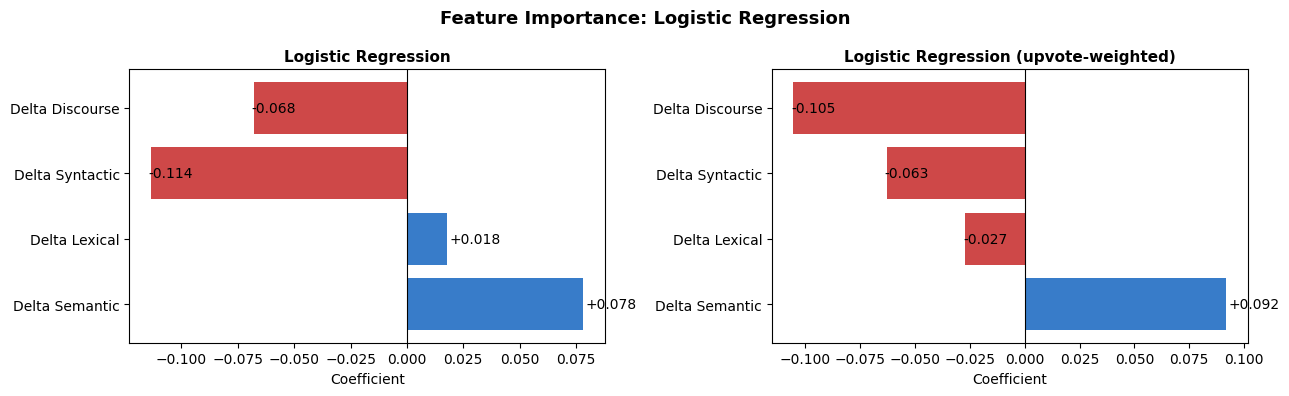

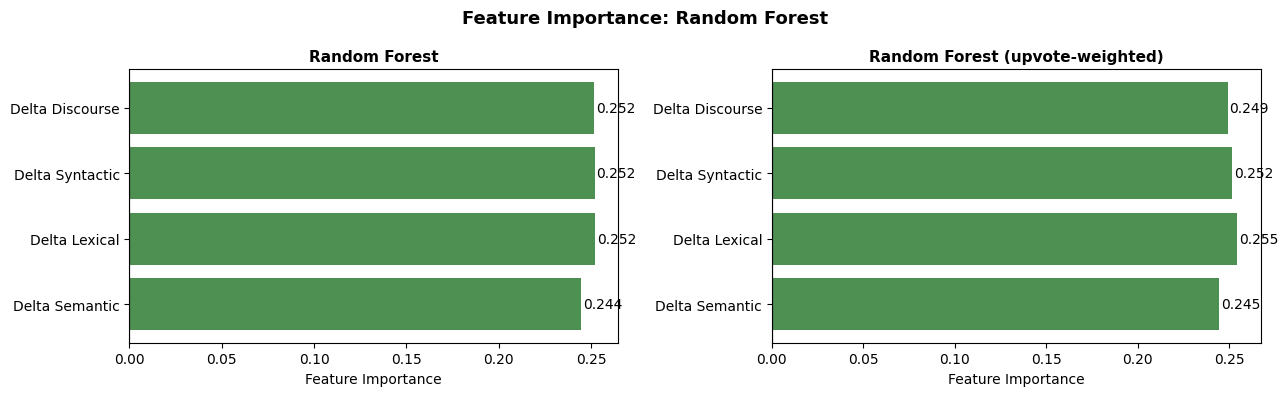

In [32]:
# Feature Importance

lr.fit(X_scaled, y)
rf.fit(X_scaled, y)
lr_w.fit(X_scaled, y, sample_weight=upvote_weights)
rf_w.fit(X_scaled, y, sample_weight=upvote_weights)

METRIC_LABELS = ['Delta Semantic', 'Delta Lexical', 'Delta Syntactic', 'Delta Discourse']

# --- Figure 1: Logistic Regression ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, suffix in [(axes[0], lr, ''), (axes[1], lr_w, ' (upvote-weighted)')]:
    vals = model.coef_[0]
    colors = ['#1565C0' if x > 0 else '#C62828' for x in vals]
    ax.barh(METRIC_LABELS, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient')
    ax.set_title(f'Logistic Regression{suffix}', fontsize=11, fontweight='bold')
    for i, x in enumerate(vals):
        ax.text(x + np.sign(x) * 0.001, i, f'{x:+.3f}', va='center', fontsize=10)

fig.suptitle('Feature Importance: Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('litbench_feature_importance_lr.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: Random Forest ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, suffix in [(axes[0], rf, ''), (axes[1], rf_w, ' (upvote-weighted)')]:
    vals = model.feature_importances_
    ax.barh(METRIC_LABELS, vals, color=['#2E7D32'] * 4, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Random Forest{suffix}', fontsize=11, fontweight='bold')
    for i, x in enumerate(vals):
        ax.text(x + 0.001, i, f'{x:.3f}', va='center', fontsize=10)

fig.suptitle('Feature Importance: Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('litbench_feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

Diversity Scores: Chosen vs. Rejected (Means)

Metric       Chosen   Rejected          Δ            Direction
--------------------------------------------------------------
D_sem        0.7947     0.7944    +0.0003  ↑ chosen more diverse 
D_lex        0.9906     0.9925    -0.0019  ↓ rejected more diverse 
D_syn        0.9596     0.9613    -0.0017  ↓ rejected more diverse 
D_disc       0.2513     0.2612    -0.0098  ↓ rejected more diverse 


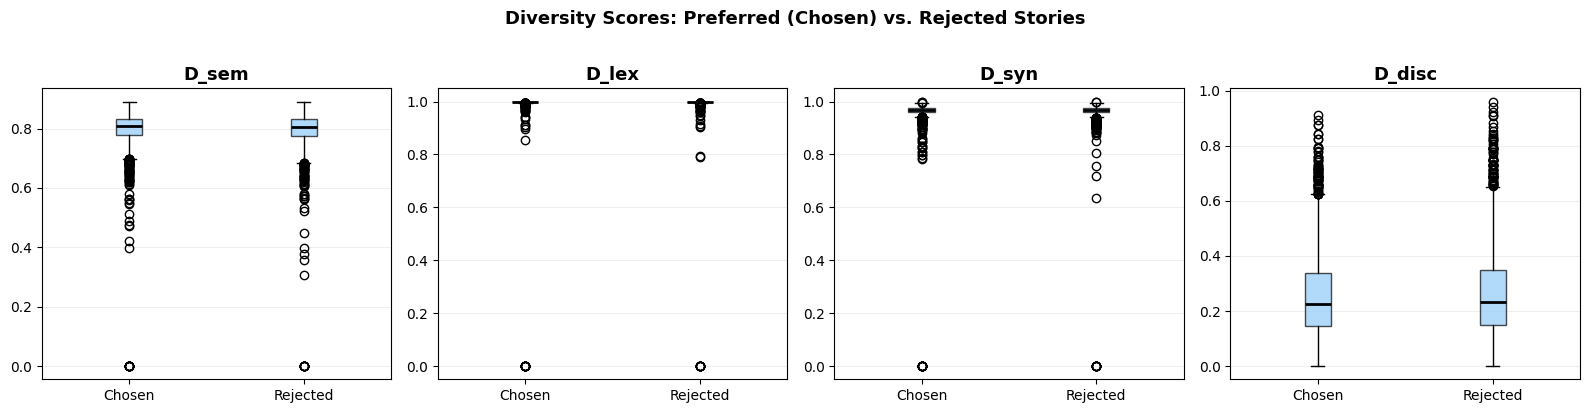

In [34]:
# Statistical comparison of means and visualization

print('Diversity Scores: Chosen vs. Rejected (Means)\n')
print(f'{"Metric":<8} {"Chosen":>10} {"Rejected":>10} {"Δ":>10} {"Direction":>20}')
print('-' * 62)

# Calculate mean differences and effect sizes for each metric
for col in chosen_df.columns:
    c_mean = chosen_df[col].mean()
    r_mean = rejected_df[col].mean()
    delta = c_mean - r_mean
    direction = '↑ chosen more diverse' if delta > 0 else '↓ rejected more diverse'
    effect_d = abs(delta) / max(np.sqrt((chosen_df[col].std()**2 + rejected_df[col].std()**2) / 2), 1e-6)
    sig = '***' if effect_d > 0.5 else '**' if effect_d > 0.3 else '*' if effect_d > 0.1 else ''
    print(f'{col:<8} {c_mean:>10.4f} {r_mean:>10.4f} {delta:>+10.4f}  {direction:<20} {sig}')

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, col in zip(axes, chosen_df.columns):
    ax.boxplot(
        [chosen_df[col].values, rejected_df[col].values],
        labels=['Chosen', 'Rejected'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(facecolor='#90CAF9', alpha=0.7),
    )
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Diversity Scores: Preferred (Chosen) vs. Rejected Stories',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig("litbench_diversity_chosen_vs_rejected.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Ablation: Accuracy per dimension (single vs. all 4) 

Dimension                      Unweighted     Weighted
-------------------------------------------------------
  Random (Baseline)                   50.0%
  All 4 (LR, unweighted)              50.0%
  All 4 (LR, weighted)                50.3%

  Only Semantic (D_sem)              49.3%        50.1%
  Only Lexical (D_lex)               50.4%        50.5%
  Only Syntactic (D_syn)             50.4%        50.3%
  Only Discourse (D_disc)            51.2%        51.2%


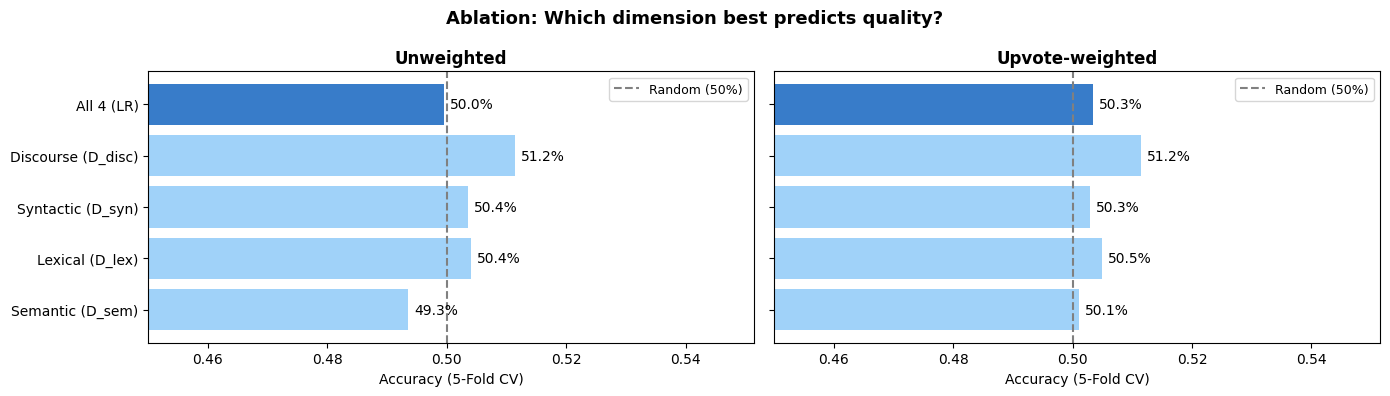

In [38]:
# Ablation: Contribution of each dimension individually vs. all 4

METRIC_NAMES_LONG = {
    'delta_D_sem':  'Semantic (D_sem)',
    'delta_D_lex':  'Lexical (D_lex)',
    'delta_D_syn':  'Syntactic (D_syn)',
    'delta_D_disc': 'Discourse (D_disc)',
}

print('Ablation: Accuracy per dimension (single vs. all 4) \n')
print(f'{"Dimension":<28} {"Unweighted":>12} {"Weighted":>12}')
print('-' * 55)
print(f'  Random (Baseline)            {"50.0%":>12}')
print(f'  All 4 (LR, unweighted)       {lr_scores.mean():>12.1%}')
print(f'  All 4 (LR, weighted)         {lr_scores_w.mean():>12.1%}')
print()

single_accs = {}
single_accs_w = {}

# Train a separate logistic regression for each individual feature (unweighted and weighted)
for col in FEATURE_COLS:
    X_single = StandardScaler().fit_transform(delta_df[[col]].values)

    lr_s = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(lr_s, X_single, y, cv=cv, scoring='accuracy')

    lr_sw = LogisticRegression(max_iter=1000, random_state=42)
    lr_sw.set_fit_request(sample_weight=True)
    scores_w = cross_val_score(lr_sw, X_single, y, cv=cv, scoring='accuracy',
                                params={'sample_weight': upvote_weights})

    single_accs[col] = scores.mean()
    single_accs_w[col] = scores_w.mean()

    label = METRIC_NAMES_LONG[col]
    print(f'  Only {label:<22} {scores.mean():>12.1%} {scores_w.mean():>12.1%}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

labels = [METRIC_NAMES_LONG[c] for c in FEATURE_COLS] + ['All 4 (LR)']

for ax, accs_map, accs_all, title in [
    (axes[0], single_accs,   lr_scores.mean(),   'Unweighted'),
    (axes[1], single_accs_w, lr_scores_w.mean(), 'Upvote-weighted'),
]:
    accs = [accs_map[c] for c in FEATURE_COLS] + [accs_all]
    colors = ['#90CAF9'] * 4 + ['#1565C0']
    bars = ax.barh(labels, accs, color=colors, alpha=0.85)
    ax.axvline(0.5, color='gray', linewidth=1.5, linestyle='--', label='Random (50%)')
    ax.set_xlabel('Accuracy (5-Fold CV)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, acc in zip(bars, accs):
        ax.text(acc + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{acc:.1%}', va='center', fontsize=10)
    ax.set_xlim(0.45, max(accs) + 0.04)
    ax.legend(fontsize=9)

fig.suptitle('Ablation: Which dimension best predicts quality?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig
plt.show()

In [40]:
# Save results to JSON

results = {
    'n_pairs': N_SAMPLE,
    'metrics': ['D_sem', 'D_lex', 'D_syn', 'D_disc'],
    'lr_accuracy': float(lr_scores.mean()),
    'lr_std': float(lr_scores.std()),
    'rf_accuracy': float(rf_scores.mean()),
    'rf_std': float(rf_scores.std()),
    'ablation_single': {col: float(acc) for col, acc in single_accs.items()},
    'lr_coefficients': dict(zip(FEATURE_COLS, lr.coef_[0].tolist())),
    'rf_importance': dict(zip(FEATURE_COLS, rf.feature_importances_.tolist())),
    'chosen_means': chosen_df.mean().to_dict(),
    'rejected_means': rejected_df.mean().to_dict(),
}

with open('litbench_quality_analysis.json', 'w') as f:
    json.dump(results, f, indent=2)